# single linear regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
p=r"C:\programming\python\jupyter\ML\files\student_data.csv"
df=pd.read_csv(p)

In [3]:
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [4]:
df.head()         #shows the first 5 table content

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [5]:
df.tail()         #shows the last 5 table content        

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [6]:
df.shape          #shows total no of rows and columns of file

(200, 2)

In [7]:
df.info()           #shows the file information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


In [8]:
df.describe()     

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


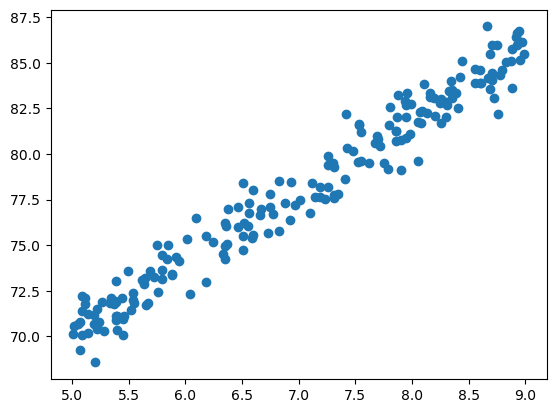

In [9]:
#step 1 - data visualization (shows the nature of graph)
plt.scatter(x=df.study_hours,y=df.student_marks)             #y is dependent variable on x
plt.show()

In [10]:
#step 2- data cleansing 
df.isnull()

,study_hours,student_marks
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False
...,...,...
195,False,False
196,False,False
197,False,False
198,False,False


In [11]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [12]:
df.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [13]:
df2=df.fillna(df.mean())                   #blank infos are filled with the mean value
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [14]:
df2.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [15]:
#after data cleansing
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [16]:
#step 3- dataset split
x=df2.drop("student_marks",axis="columns")          # it is used to ignore the column ("column name", axis="columns")
y=df2.drop("study_hours", axis="columns")

In [17]:
x.shape   #shows the shape of dataset

(200, 1)

In [18]:
y.shape

(200, 1)

In [19]:
x

,study_hours
0,6.830000
1,6.560000
2,6.995949
3,5.670000
4,8.670000
...,...
195,7.530000
196,8.560000
197,8.940000
198,6.600000


In [20]:
y

,student_marks
0,78.50
1,76.74
2,78.68
3,71.82
4,84.19
...,...
195,81.67
196,84.68
197,86.75
198,78.05


In [21]:
#training and testing dataset
from sklearn.model_selection import train_test_split

In [22]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.2,random_state=51)    
#train_test_split divides the dataset into two parts i.e training and testing. (test_size= .2 means 20% for test set and
# rest of all for train set, )

In [23]:
x_train.shape

(160, 1)

In [24]:
x_test.shape

(40, 1)

In [25]:
y_train.shape

(160, 1)

In [26]:
y_test.shape

(40, 1)

In [27]:
x_test

,study_hours
148,8.300000
104,7.230000
4,8.670000
7,8.990000
192,8.710000
160,7.700000
118,5.690000
58,5.390000
190,5.790000
174,5.390000


In [28]:
#step4- applying linear regression to trainlr model
from sklearn.linear_model import LinearRegression

In [29]:
lr=LinearRegression()

In [30]:
#applying train dataset to linear regression
lr.fit(x_train,y_train)       #fit is used to create a machine (m and c are generated, of y=mx+c)


LinearRegression()

In [31]:
lr.coef_             #used to show the value of m (slope) 

array([[3.93571802]])

In [32]:
lr.intercept_         #used to find the value of constatnt term C

array([50.44735504])

In [33]:
#calculating the value (mathematically) if a student studies 4 hours, then the output will be passing percentage----1
m=3.93
c=50.44
# y=mx+c
y=m*4+c
print(y)

66.16


In [34]:
#predicting the value using the model-------2
lr.predict([[4]]) 

C:\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[66.1902271]])

In [35]:
lr.predict([[4]])[0][0]

C:\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


66.19022710353573

In [36]:
lr.predict([[4]])[0][0].round(2)  #it is used to roundoff

C:\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


66.19

In [37]:
#predctiong the value using ML model (testing set)
y_predict=lr.predict(x_test)
y_predict

array([[83.11381458],
       [78.9025963 ],
       [84.57003024],
       [85.82946001],
       [84.72745896],
       [80.75238377],
       [72.84159055],
       [71.66087515],
       [73.23516235],
       [71.66087515],
       [73.47130543],
       [76.38373677],
       [73.23516235],
       [73.58937697],
       [82.95638585],
       [70.40144538],
       [73.23516235],
       [78.74516758],
       [75.55723598],
       [82.68088559],
       [76.65923703],
       [70.48015974],
       [74.77009238],
       [77.98143645],
       [85.59331693],
       [82.56281405],
       [76.42309395],
       [85.0423164 ],
       [78.39095296],
       [81.38209865],
       [81.73631327],
       [83.15317176],
       [82.20859943],
       [81.10659839],
       [73.58937697],
       [71.1492318 ],
       [71.89701823],
       [81.53952737],
       [72.60544747],
       [71.93637541]])

In [38]:
y_test

,student_marks
148,82.02
104,77.55
4,84.19
7,85.46
192,84.03
160,80.81
118,73.61
58,70.90
190,73.14
174,73.02


In [39]:
pd.DataFrame(np.c_[x_test,y_test,y_predict],columns=["study_hours","student_marks","predict_marks"])

,study_hours,student_marks,predict_marks
0,8.300000,82.02,83.113815
1,7.230000,77.55,78.902596
2,8.670000,84.19,84.570030
3,8.990000,85.46,85.829460
4,8.710000,84.03,84.727459
5,7.700000,80.81,80.752384
6,5.690000,73.61,72.841591
7,5.390000,70.90,71.660875
8,5.790000,73.14,73.235162
9,5.390000,73.02,71.660875


In [40]:
#checking the accuracy of ML model in percentage
lr.score(x_test,y_test)

0.9514124242154464

In [41]:
import joblib #it is used to generate a pkl file

In [42]:
joblib.dump(lr,"predict_marks.pkl")

['predict_marks.pkl']